In [1]:
from utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies

df = get_match_df()

df.head()

,date,time,league,home_team,away_team,strategy,result,return,week
match_id,,,,,,,,,
d19427657,2026-01-07,20:30,Premier League,AFC Bournemouth,Tottenham Hotspur,Win Goal,True,0.5,1
d19427661,2026-01-07,20:30,Premier League,Everton,Wolverhampton Wanderers,CN Home,False,-1.0,1
d19577432,2026-01-09,09:35,Australia,Brisbane Roar,Auckland,Multigoal 1-3 Away,True,0.3,1
d19577432,2026-01-09,09:35,Australia,Brisbane Roar,Auckland,Goal HT,True,0.5,1
d19433614,2026-01-09,20:30,Bundesliga,Eintracht Frankfurt,Borussia Dortmund,Win Goal,True,0.5,1


## Approccio 1: Scommetto tutti i mercati e tutti i campionati

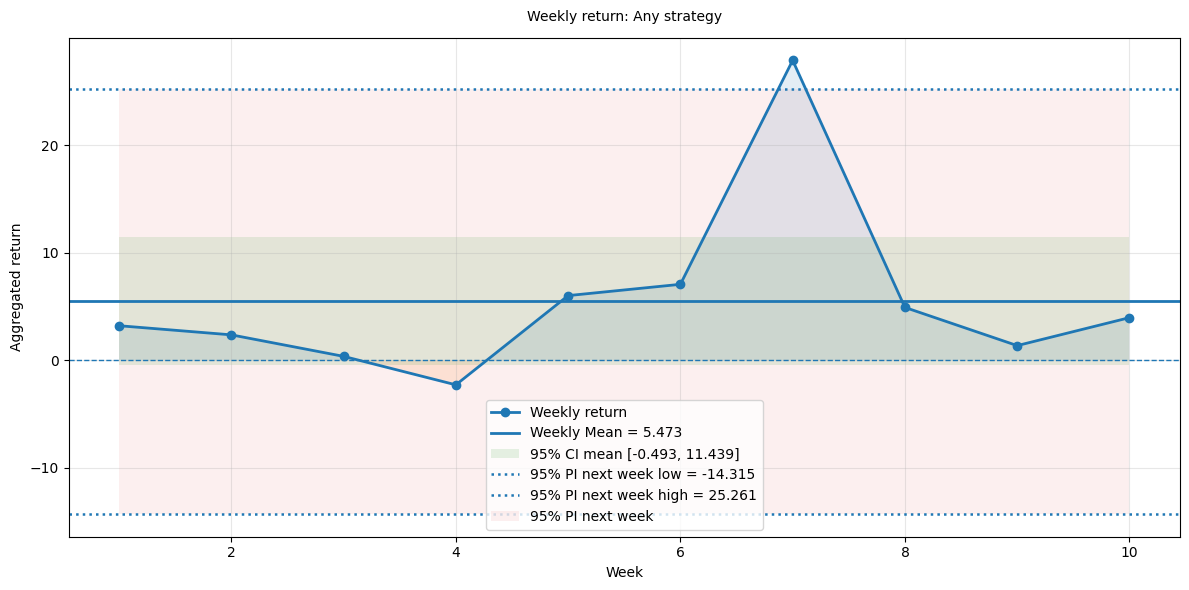

In [2]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [3]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
BTTS,3.21,9.53,6.00,60,0.75
DNB 1,0.92,2.36,8.60,86,0.75
Over 1.5 (M2-X),0.71,2.12,7.30,73,0.78
Goal HT,0.40,1.91,5.00,50,0.82
Win x2 HT,0.40,1.67,2.20,22,0.63
Over 0.5 HT (Live),0.37,1.65,5.20,52,0.79
Win 2,0.28,0.83,1.70,17,0.74
CN Home (Asiatic),0.23,1.11,3.10,31,0.60
Win 1,0.11,1.02,2.00,20,0.72
Multigoal 1-2 Home,-0.16,1.12,0.70,7,0.70


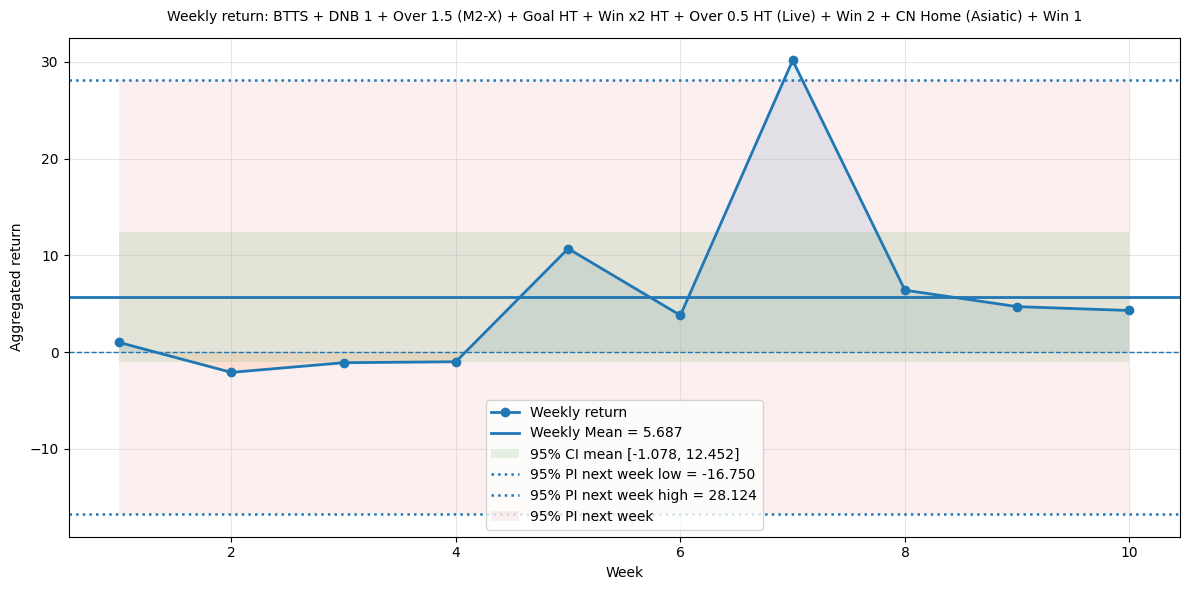

In [4]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

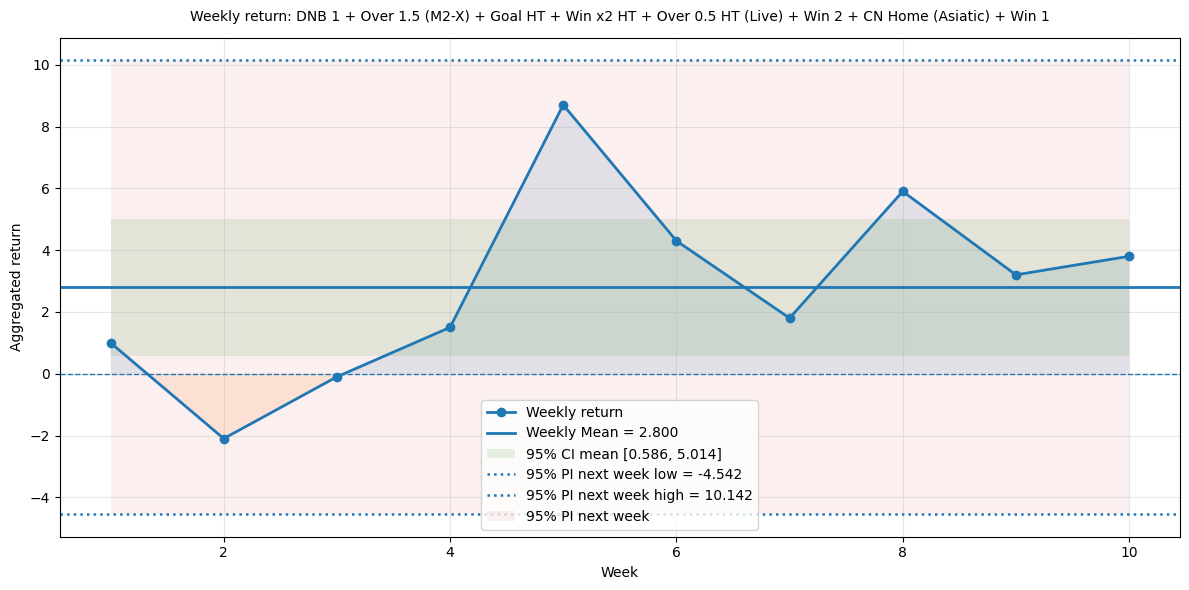

In [5]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

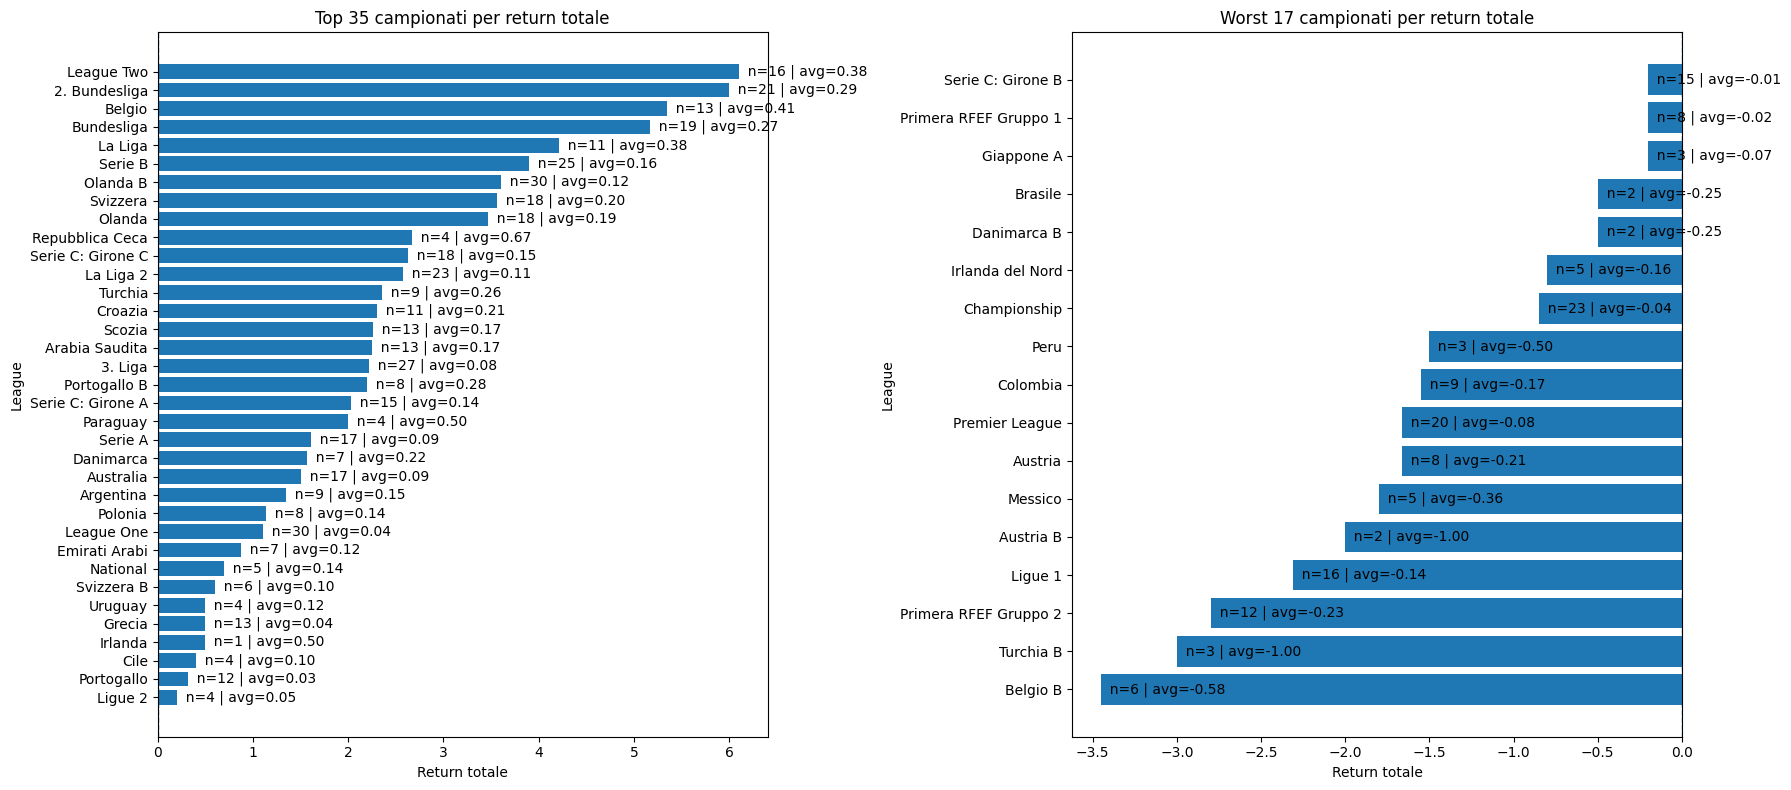

In [6]:
best_leagues = get_best_leagues(df)

In [7]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=list(best_leagues.index))

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
BTTS,2.97,7.84,5.10,51,0.81
DNB 1,1.28,2.41,6.60,66,0.84
Win x2 HT,1.02,1.50,1.70,17,0.81
Over 1.5 (M2-X),0.79,1.70,4.70,47,0.82
Goal HT,0.65,1.49,3.70,37,0.85
Over 0.5 HT (Live),0.56,1.36,3.90,39,0.83
Win 2,0.50,0.79,1.50,15,0.83
Win 1,0.44,0.62,1.30,13,0.88
DNB 2,0.33,1.39,4.00,40,0.75
Multigoal 1-2 Home,0.16,0.78,0.40,4,0.75


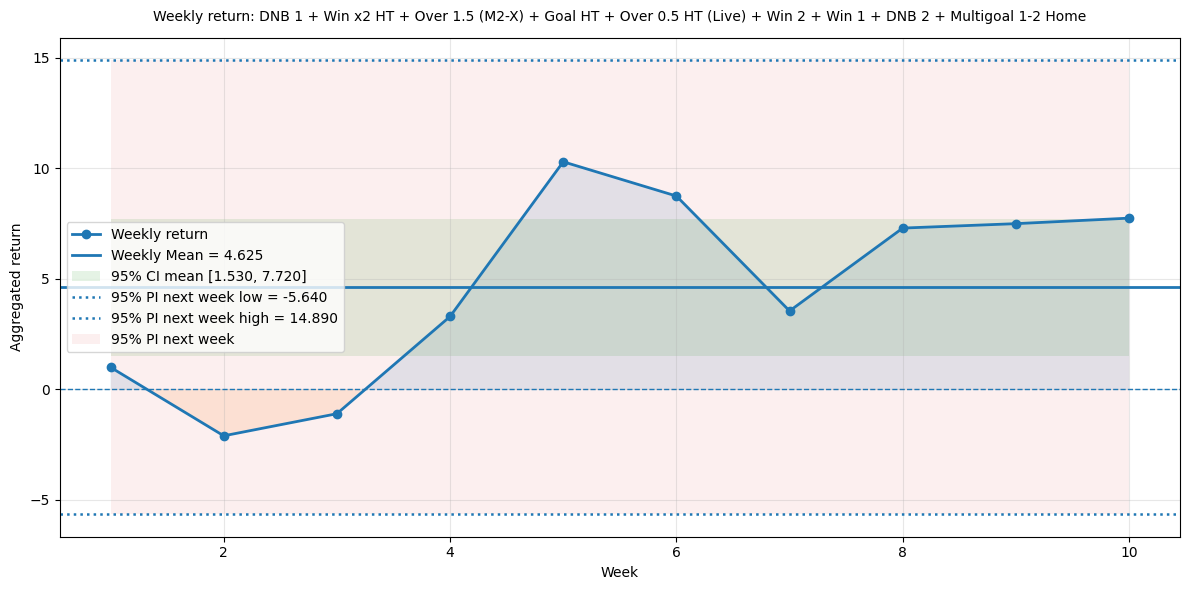

In [8]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['DNB 1', 'Win x2 HT', 'Over 1.5 (M2-X)', 'Goal HT',
       'Over 0.5 HT (Live)', 'Win 2', 'Win 1', 'DNB 2', 'Multigoal 1-2 Home']

weekly_return, stats = analyze_strategies(df, strategies=best_strategies, leagues=list(best_leagues.index), print_pi=True)

### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto

In [9]:
weekly_return

week
1     1.00
2    -2.10
3    -1.10
4     3.30
5    10.30
6     8.75
7     3.55
8     7.30
9     7.50
10    7.75
Name: return, dtype: float64

In [10]:
stats

{'strategy': ['DNB 1',
  'Win x2 HT',
  'Over 1.5 (M2-X)',
  'Goal HT',
  'Over 0.5 HT (Live)',
  'Win 2',
  'Win 1',
  'DNB 2',
  'Multigoal 1-2 Home'],
 'leagues': ['League Two',
  '2. Bundesliga',
  'Belgio',
  'Bundesliga',
  'La Liga',
  'Serie B',
  'Olanda B',
  'Svizzera',
  'Olanda',
  'Repubblica Ceca',
  'Serie C: Girone C',
  'La Liga 2',
  'Turchia',
  'Croazia',
  'Scozia',
  'Arabia Saudita',
  '3. Liga',
  'Portogallo B',
  'Serie C: Girone A',
  'Paraguay',
  'Serie A',
  'Danimarca',
  'Australia',
  'Argentina',
  'Polonia',
  'League One',
  'Emirati Arabi',
  'National',
  'Svizzera B',
  'Grecia',
  'Irlanda',
  'Uruguay',
  'Cile',
  'Portogallo',
  'Ligue 2'],
 'n_weeks': 10,
 'mean_weekly_agg_return': np.float64(4.625),
 'std_weekly_agg_return': np.float64(4.3264207685645495),
 'sem': np.float64(1.3681343744920185),
 'ci_low': np.float64(1.5300650249959675),
 'ci_high': np.float64(7.7199349750040325),
 'pi_low': np.float64(-5.639738062636344),
 'pi_high': np.fl